# Inspect produced 10K mDST Parquet shards

Bounded, real-data-only inspection of representative valid
shards from every physics category in the 10K campaign. The
campaign-status notebook owns exhaustive global validation;
this notebook owns readable event/node/content inspection.

## tl;dr

In [1]:
from collections import Counter
from itertools import islice
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CAMPAIGN_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_CAMPAIGN_ROOT",
    "/data/dust/user/boyangyu/hypertagging/production_10k_middle_20260804",
))
MANIFEST = Path(os.environ.get(
    "HYPERTAGGING_10K_MANIFEST",
    CAMPAIGN_ROOT / "manifests" / "mdst_10k_random_seed_20260804_v3.jsonl",
))
SOURCE_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_SOURCE_ROOT",
    CAMPAIGN_ROOT / "source" / "d02e823e0cbc",
))
REPORT_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_REPORT_ROOT", CAMPAIGN_ROOT / "inspection"
))
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path[:0] = [str(SOURCE_ROOT), str(SOURCE_ROOT / "src")]
from scripts import mdst_batch_production as production
from hypertagging.preprocessing.schema_v4 import iter_event_records_v4

records = production.read_manifest(MANIFEST)
status = production.production_status(MANIFEST)
if status["missing_or_invalid"]:
    raise RuntimeError(f"Inspect only a complete valid campaign: {status['classifications']}")
rows_by_category = {}
for row in records:
    rows_by_category.setdefault(row["physics_category"], row)
max_events_per_category = int(os.environ.get(
    "HYPERTAGGING_INSPECTION_EVENTS_PER_CATEGORY", "50"
))
print(json.dumps({
    "campaign_id": status["campaign_id"],
    "valid_shards": status["complete"],
    "representative_categories": sorted(rows_by_category),
    "bounded_events_per_category": max_events_per_category,
}, indent=2))

{
  "campaign_id": "campaign-6929dab450f3-35d8a1e19134",
  "valid_shards": 20,
  "representative_categories": [
    "ccbar",
    "charged",
    "ddbar",
    "mixed",
    "ssbar",
    "taupair",
    "uubar"
  ],
  "bounded_events_per_category": 50
}


## Context & Methods

### Key Assumptions

One manifest-bound, `COMPLETE_VALID` shard is selected from
each category. Up to 50 events per selected shard are loaded;
therefore distribution plots are diagnostic samples, not
production-wide physics estimates.

In [2]:
selected_rows = [rows_by_category[key] for key in sorted(rows_by_category)]
validation_rows = []
for row in selected_rows:
    result = production.classify_shard(
        Path(row["output_file"]), **production._validation_kwargs(row)
    )
    validation_rows.append({
        "task_id": row["task_id"],
        "category": row["physics_category"],
        "output_file": row["output_file"],
        "classification": result["classification"],
    })
validation_frame = pd.DataFrame(validation_rows)
assert validation_frame.classification.eq("COMPLETE_VALID").all()
display(validation_frame)

,task_id,category,output_file,classification
0,0,ccbar,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
1,1,charged,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
2,2,ddbar,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
3,3,mixed,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
4,4,ssbar,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
5,5,taupair,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID
6,6,uubar,/data/dust/user/boyangyu/hypertagging/producti...,COMPLETE_VALID


## Data

In [3]:
sampled_events = []
for row in selected_rows:
    path = Path(row["output_file"])
    for event in islice(iter_event_records_v4(path), max_events_per_category):
        event = dict(event)
        event["_inspection_category"] = row["physics_category"]
        event["_inspection_shard"] = str(path)
        sampled_events.append(event)
if not sampled_events:
    raise RuntimeError("No events were loaded from valid shards")
event_rows = []
node_rows = []
for event in sampled_events:
    nodes = event["nodes"]
    event_rows.append({
        "event_uid": event["event_uid"],
        "category": event["_inspection_category"],
        "nodes": len(nodes),
        "maximum_depth": max((int(node.get("level", 0)) for node in nodes), default=0),
        "active_nodes": sum(bool(node.get("active", False)) for node in nodes),
    })
    for node in nodes:
        node_rows.append({
            "event_uid": event["event_uid"],
            "category": event["_inspection_category"],
            "node_kind": node.get("node_kind", "unknown"),
            "level": int(node.get("level", -1)),
            "pdg": int(node.get("pdg", 0)),
            "pid_target_token": int(node.get("pid_target_token", node.get("token", -1))),
            "is_leaf": not bool(node.get("daughter_ids")),
            "active": bool(node.get("active", False)),
        })
events_frame = pd.DataFrame(event_rows)
nodes_frame = pd.DataFrame(node_rows)
assert events_frame.event_uid.is_unique
display(events_frame.groupby("category").agg(
    events=("event_uid", "size"),
    mean_nodes=("nodes", "mean"),
    max_nodes=("nodes", "max"),
    max_depth=("maximum_depth", "max"),
))
display(nodes_frame.head(20))

,events,mean_nodes,max_nodes,max_depth
category,,,,
ccbar,50,49.32,71,4
charged,50,59.40,78,6
ddbar,50,40.34,61,2
mixed,50,59.12,86,6
ssbar,50,38.96,63,2
taupair,50,25.74,43,1
uubar,50,35.80,56,2


,event_uid,category,node_kind,level,pdg,pid_target_token,is_leaf,active
0,1004:0:11727085:52205,ccbar,composite,4,423,19,False,True
1,1004:0:11727085:52205,ccbar,track,0,211,9,True,True
2,1004:0:11727085:52205,ccbar,composite,3,421,15,False,True
3,1004:0:11727085:52205,ccbar,composite,1,111,4,False,True
4,1004:0:11727085:52205,ccbar,track,0,-211,26,True,True
5,1004:0:11727085:52205,ccbar,composite,1,111,4,False,True
6,1004:0:11727085:52205,ccbar,composite,2,-411,31,False,True
7,1004:0:11727085:52205,ccbar,track,0,211,9,True,True
8,1004:0:11727085:52205,ccbar,composite,1,310,6,False,True
9,1004:0:11727085:52205,ccbar,composite,2,310,6,False,True


## Results

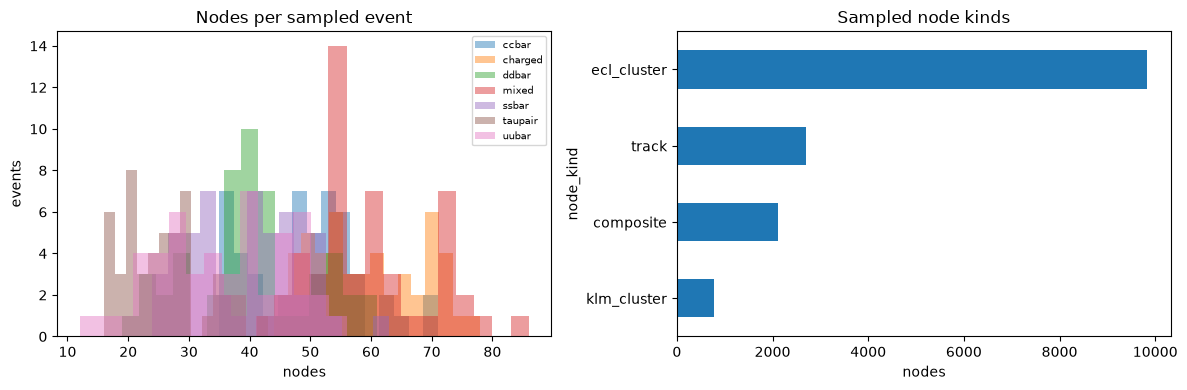

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for category, group in events_frame.groupby("category"):
    axes[0].hist(group.nodes, bins=15, alpha=.45, label=category)
axes[0].set(title="Nodes per sampled event", xlabel="nodes", ylabel="events")
axes[0].legend(fontsize=7)
kind_counts = nodes_frame.node_kind.value_counts().sort_values()
kind_counts.plot.barh(ax=axes[1], title="Sampled node kinds")
axes[1].set_xlabel("nodes")
plt.tight_layout()
plt.savefig(REPORT_ROOT / "sampled_event_node_distributions.png", dpi=140)
plt.show()

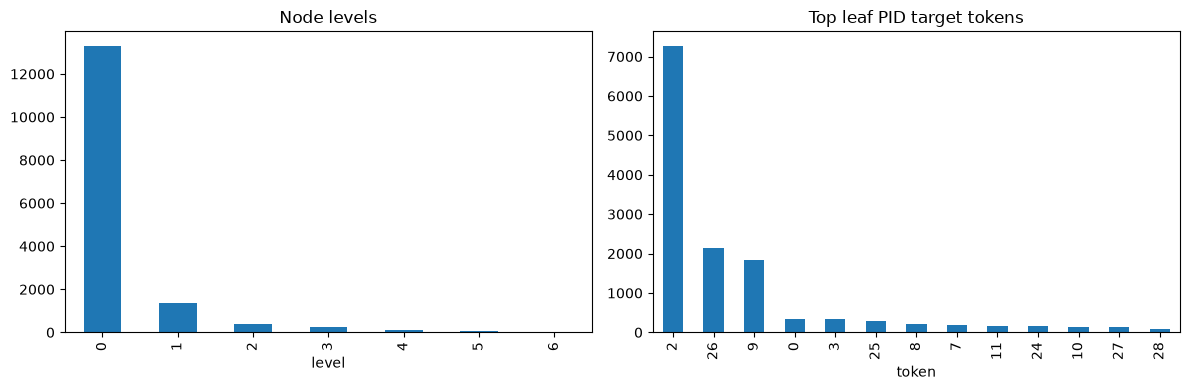

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nodes_frame.level.value_counts().sort_index().plot.bar(
    ax=axes[0], title="Node levels"
)
leaf_pid = nodes_frame.loc[nodes_frame.is_leaf, "pid_target_token"].value_counts().head(20)
leaf_pid.plot.bar(ax=axes[1], title="Top leaf PID target tokens")
axes[0].set_xlabel("level")
axes[1].set_xlabel("token")
plt.tight_layout()
plt.savefig(REPORT_ROOT / "sampled_levels_and_pid.png", dpi=140)
plt.show()

In [6]:
example = sampled_events[0]
example_nodes = {int(node["node_id"]): node for node in example["nodes"]}
edge_rows = []
for parent_id, parent in example_nodes.items():
    for child_id in parent.get("daughter_ids", []):
        child = example_nodes.get(int(child_id), {})
        edge_rows.append({
            "parent_id": parent_id,
            "parent_pdg": parent.get("pdg"),
            "child_id": int(child_id),
            "child_pdg": child.get("pdg"),
            "child_kind": child.get("node_kind"),
        })
print({
    "example_event_uid": example["event_uid"],
    "category": example["_inspection_category"],
    "nodes": len(example_nodes),
    "edges": len(edge_rows),
})
display(pd.DataFrame(edge_rows).head(40))

{'example_event_uid': '1004:0:11727085:52205', 'category': 'ccbar', 'nodes': 51, 'edges': 20}


,parent_id,parent_pdg,child_id,child_pdg,child_kind
0,2,423,4,421,composite
1,2,423,5,111,composite
2,4,421,10,310,composite
3,4,421,11,310,composite
4,4,421,12,-321,track
5,4,421,13,211,track
6,5,111,14,22,ecl_cluster
7,7,111,16,22,ecl_cluster
8,7,111,17,22,ecl_cluster
9,8,-411,18,310,composite


## Takeaways

In [7]:
category_summary = events_frame.groupby("category").agg(
    events=("event_uid", "size"),
    mean_nodes=("nodes", "mean"),
    maximum_nodes=("nodes", "max"),
    maximum_depth=("maximum_depth", "max"),
).reset_index().to_dict(orient="records")
report = {
    "artifact": "real_10k_bounded_output_inspection",
    "fixture_or_real": "real",
    "manifest": str(MANIFEST),
    "campaign_id": status["campaign_id"],
    "validated_representative_shards": validation_rows,
    "sampled_events": len(sampled_events),
    "sampled_nodes": len(nodes_frame),
    "unique_sampled_event_uids": int(events_frame.event_uid.nunique()),
    "category_summary": category_summary,
    "node_kind_distribution": {
        str(key): int(value) for key, value in nodes_frame.node_kind.value_counts().items()
    },
    "pass_fail_status": "PASS",
    "sampling_caveat": "bounded representative content inspection; see campaign_status_report.json for exhaustive validation",
}
report_path = REPORT_ROOT / "shard_inspection_report.json"
report_path.write_text(json.dumps(report, indent=2, sort_keys=True))
print(json.dumps({
    "report": str(report_path),
    "pass_fail_status": report["pass_fail_status"],
    "sampled_events": report["sampled_events"],
    "sampled_nodes": report["sampled_nodes"],
}, indent=2))

{
  "report": "/data/dust/user/boyangyu/hypertagging/production_10k_middle_20260804/inspection/shard_inspection_report.json",
  "pass_fail_status": "PASS",
  "sampled_events": 350,
  "sampled_nodes": 15434
}
